In [1]:
from bs4 import BeautifulSoup
import pandas as pd
import json
import requests
import time
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.core.display import HTML
import html

# Beers

In [2]:
# Load the HTML file
with open("untappd_data_unformatted.html", "r", encoding="utf-8") as file:
    html_content = file.read()

# Parse the HTML using BeautifulSoup
soup = BeautifulSoup(html_content, "html.parser")

# Find all the beer items in the HTML
beer_items = soup.find_all("div", class_="beer-item")

# Initialize empty lists to store the extracted data
beer_names = []
brewery_names = []
styles = []  # New list for beer styles
abvs = []  # New list for ABV (Alcohol By Volume)
your_ratings = []
global_ratings = []
image_urls = []
beer_urls = []
brewery_paths = []  # New list for brewery file paths

# Loop through each beer item and extract the desired information
for item in beer_items:
    # Extract beer name
    # beer_name = item.find("p", class_="name").find("a").text
    # beer_names.append(beer_name)
    # Extract beer name and unescape special characters
    beer_name = html.unescape(item.find("p", class_="name").find("a").text)
    beer_names.append(beer_name)


    # Extract brewery name
    brewery_name = html.unescape(item.find("p", class_="brewery").find("a").text)
    brewery_names.append(brewery_name)

    # Extract beer style
    style = item.find("p", class_="style").text
    styles.append(style)

    # Extract ABV (Alcohol By Volume) and remove the "ABV" text
    abv_text = item.find("p", class_="abv").text
    abv_percentage = abv_text.replace("ABV", "").strip()
    #.replace('%', '')
    # abvs.append(float(abv_percentage) / 100 if abv_percentage else None)
    abvs.append(abv_percentage if abv_percentage else None)


    # Extract your rating and remove the text
    your_rating_text = item.find("div", class_="you").find("p").text
    your_rating = your_rating_text.split("(")[1].replace(")", "")
    your_ratings.append(float(your_rating) if your_rating != "N/A" else None)

    # Extract global rating and remove the text
    global_rating_text = item.find("div", class_="you").find_next_sibling("div").find("p").text
    global_rating = global_rating_text.split("(")[1].replace(")", "")
    global_ratings.append(float(global_rating) if global_rating != "N/A" else None)

    # Extract label image URL
    image_url = item.find("a", class_="label").find("img")["src"]
    image_urls.append(image_url)

    # Extract beer URL
    beer_url = item.find("p", class_="name").find("a")["href"]
    beer_urls.append(beer_url)

    # Extract brewery filepath
    brewery_path = item.find("p", class_="brewery").find("a")["href"]
    brewery_paths.append(brewery_path)

# Create a Pandas DataFrame with the specified column order
data = {
    "Beer Name": beer_names,
    "Brewery Name": brewery_names,
    "Style": styles,
    "ABV": abvs,
    "My Rating": your_ratings,
    "Global Rating": global_ratings,
    "Beer URL": beer_urls,
    "Brewery Filepath": brewery_paths,
    "Image URL": image_urls
}

df = pd.DataFrame(data)

# add https://untappd.com/ to the beginning of the brewery path
df['Brewery Filepath'] = 'https://untappd.com' + df['Brewery Filepath']

# add https://untappd.com/beer/ to the beginning of the beer path
df['Beer URL'] = 'https://untappd.com' + df['Beer URL']

# Convert "My Rating" and "Global Rating" columns to numeric
df["My Rating"] = pd.to_numeric(df["My Rating"], errors="coerce")
df["Global Rating"] = pd.to_numeric(df["Global Rating"], errors="coerce")

# add diff column
df['diff'] = df['My Rating'] - df['Global Rating']

# sort by My Rating (descending)
df = df.sort_values(by=['My Rating'], ascending=False)

# Preview DataFrame
df

,Beer Name,Brewery Name,Style,ABV,My Rating,Global Rating,Beer URL,Brewery Filepath,Image URL,diff
227,Double Citra,Hill Farmstead Brewery,IPA - Imperial / Double,8%,5.00,4.50,https://untappd.com/b/hill-farmstead-brewery-d...,https://untappd.com/HillFarmsteadBrewery,https://assets.untappd.com/site/beer_logos/bee...,0.50
26,Double Nelson,Hill Farmstead Brewery,IPA - Imperial / Double,8%,5.00,4.41,https://untappd.com/b/hill-farmstead-brewery-d...,https://untappd.com/HillFarmsteadBrewery,https://assets.untappd.com/site/beer_logos/bee...,0.59
210,Nelson Single Hop Pale Ale,Hill Farmstead Brewery,Pale Ale - American,5%,4.75,4.26,https://untappd.com/b/hill-farmstead-brewery-n...,https://untappd.com/HillFarmsteadBrewery,https://assets.untappd.com/site/beer_logos/bee...,0.49
10,Jasper with Nelson,Fidens Brewing Co,IPA - Imperial / Double New England / Hazy,7.9%,4.75,4.44,https://untappd.com/b/fidens-brewing-co-jasper...,https://untappd.com/w/fidens-brewing-co/426930,https://assets.untappd.com/site/beer_logos/bee...,0.31
213,Haze,Tree House Brewing Company,IPA - Imperial / Double,8.2%,4.75,4.47,https://untappd.com/b/tree-house-brewing-compa...,https://untappd.com/treehousebrewco,https://assets.untappd.com/site/beer_logos/bee...,0.28
...,...,...,...,...,...,...,...,...,...,...
330,Lunch Money,Queen City Brewing,Stout - Milk / Sweet,5.3%,2.50,3.48,https://untappd.com/b/queen-city-brewing-lunch...,https://untappd.com/QCBrewing,https://assets.untappd.com/site/assets/images/...,-0.98
5,Dunley Place,Aslin Beer Company,IPA - Imperial / Double,8%,2.50,4.12,https://untappd.com/b/aslin-beer-company-dunle...,https://untappd.com/AslinBeerCompany,https://assets.untappd.com/site/beer_logos/bee...,-1.62
4,Drippin' on the Cheap,Aslin Beer Company,IPA - Imperial / Double,8.5%,2.25,4.08,https://untappd.com/b/aslin-beer-company-dripp...,https://untappd.com/AslinBeerCompany,https://assets.untappd.com/site/beer_logos/bee...,-1.83
103,Fruit Salada,Birrificio Artigianale Lariano,Sour - Fruited Gose,5%,2.00,3.40,https://untappd.com/b/birrificio-artigianale-l...,https://untappd.com/w/birrificio-artigianale-l...,https://assets.untappd.com/site/beer_logos/bee...,-1.40


In [3]:
# get list of unique styles
styles = df[['Style']].drop_duplicates().reset_index(drop=True)
# export to csv
styles.to_csv('styles.csv', index=False)

## Style adjustments

In [4]:
# import styles_cross
styles_cross = pd.read_excel('styles_cross.xlsx')

# merge styles_cross with df
df = pd.merge(df, styles_cross, how='left', on='Style')

# manually change style family to Sours+Farmhouse+Wild if Beer Name is Dwell (Batch 1)
df.loc[df['Beer Name'] == 'Dwell (Batch 1)', 'Style Family'] = 'Sours+Farmhouse+Wild'

# count beers with missing style families
print("Number of beers with missing style families: " + str(df['Style Family'].isnull().sum()))

Number of beers with missing style families: 0


In [5]:
# calculate average, median, and first quartile of 'My Rating' and 'Global Rating' by 'Style Family'
style_df = df.groupby(['Style Family']).agg({
    'My Rating': ['mean', 'median', lambda x: x.quantile(0.25)],
    'Global Rating': ['mean', 'median', lambda x: x.quantile(0.25)]
}).reset_index()

style_df.columns = ['Style Family', 'My Rating Mean', 'My Rating Median', 'My Rating First Quartile', 'Global Rating Mean', 'Global Rating Median', 'Global Rating First Quartile']

# sort by My Rating Mean (descending)
style_df = style_df.sort_values(by=['My Rating Mean'], ascending=False)

style_df

,Style Family,My Rating Mean,My Rating Median,My Rating First Quartile,Global Rating Mean,Global Rating Median,Global Rating First Quartile
4,Smoked,4.125000,4.125,3.9375,3.780833,3.77,3.6925
5,Sours+Farmhouse+Wild,4.019737,4.000,3.7500,4.026053,4.08,3.9625
6,Stouts+Porters,3.921053,4.000,3.7500,4.211111,4.28,4.1225
2,IPAs+,3.843137,4.000,3.7500,4.070542,4.07,3.8800
7,Wheat,3.788462,3.750,3.5000,3.672308,3.68,3.6200
1,Belgian,3.666667,3.500,3.5000,3.850000,3.96,3.7700
3,Lagers+,3.627451,3.500,3.5000,3.486078,3.55,3.3200
0,Ales - Other,3.500000,3.500,3.2500,3.580000,3.63,3.3600


In [6]:
# # keep only Style Family and My Rating First Quartile
# style_rlevel = style_df[['Style Family', 'My Rating First Quartile']]
# # rename My Rating First Quartile to Replacement Level
# style_rlevel = style_rlevel.rename(columns={'My Rating First Quartile': 'Replacement Level'})

In [7]:
# # keep only Style Family and My Rating First Quartile
# style_rlevel = style_df[['Style Family', 'My Rating Median']]
# # rename My Rating First Quartile to Replacement Level
# style_rlevel = style_rlevel.rename(columns={'My Rating Median': 'Replacement Level'})

In [8]:
# keep only Style Family and My Rating First Quartile
style_rlevel = style_df[['Style Family', 'My Rating Mean']]
# rename My Rating First Quartile to Replacement Level
style_rlevel = style_rlevel.rename(columns={'My Rating Mean': 'Replacement Level'})

In [9]:
# create dictionary of style adjustments
# adjustments = {
#     'Smoked': 0.5,
#     'Sours+Farmhouse+Wild': 0.25,
#     'Stouts+Porters': 0,
#     'IPAs+': 0.25,
#     'Wheat': 0,
#     'Belgian': 0,
#     'Lagers+': 0,
#     'Ales - Other': 0
# }

adjustments = {
    'Smoked': 1.5,
    'Sours+Farmhouse+Wild': 1.5,
    'Stouts+Porters': 1,
    'IPAs+': 1.5,
    'Wheat': 1,
    'Belgian': 1,
    'Lagers+': 1,
    'Ales - Other': 0.75
}

# create new column with adjustments
style_rlevel['Style Adjustment'] = style_rlevel['Style Family'].map(adjustments)

style_rlevel

,Style Family,Replacement Level,Style Adjustment
4,Smoked,4.125000,1.50
5,Sours+Farmhouse+Wild,4.019737,1.50
6,Stouts+Porters,3.921053,1.00
2,IPAs+,3.843137,1.50
7,Wheat,3.788462,1.00
1,Belgian,3.666667,1.00
3,Lagers+,3.627451,1.00
0,Ales - Other,3.500000,0.75


In [10]:
# merge to df
df = pd.merge(df, style_rlevel, how='left', on='Style Family')

In [11]:
# calculate VORB (Value Over Replacement Beer)
df['VORB'] = df['My Rating'] - df['Replacement Level']
# adjust VORB for styles
# df['VORB'] = df['VORB'] + df['Style Adjustment']
df['VORB_weight'] = df['VORB'] * df['Style Adjustment']

In [12]:
# collapse by brewery
VORB_df = df.groupby(['Brewery Name']).agg({
    'VORB': ['mean', 'max', 'count'], 'VORB_weight': ['sum'], 'Style Adjustment': ['sum']
}).reset_index()

# rename columns
VORB_df.columns = ['Brewery Name', 'VORB Mean', 'VORB Max', 'Beer Count', 'VORB_weight_sum', 'Style_Adjustment_sum']

# get weighted average VORB
#VORB_df['VORB_weighted'] = VORB_df['VORB_weight_sum'] / VORB_df['Style_Adjustment_sum']

# get weighted average VORB without max (not quite right)
VORB_df['VORB_weighted'] = (VORB_df['VORB_weight_sum'] - VORB_df['VORB Max']) / (VORB_df['Style_Adjustment_sum'] - 1)

# drop VORB_weight and Style Adjustment
VORB_df = VORB_df.drop(columns=['VORB_weight_sum', 'Style_Adjustment_sum'])

# calculate mean without max
#VORB_df['VORB Mean'] = (VORB_df['VORB Mean'] * VORB_df['Beer Count'] - VORB_df['VORB Max']) / (VORB_df['Beer Count'] - 1)

# keep only breweries with 3 or more beers
VORB_df = VORB_df[VORB_df['Beer Count'] >= 3]

# calculate weighted average of VORB Mean and VORB Max
# VORB_df['VORB'] = VORB_df['VORB Mean'] * 0.5 + VORB_df['VORB Max']*0.5
VORB_df['VORB'] = VORB_df['VORB_weighted'] * 0.5 + VORB_df['VORB Max'] * 0.5

# sort by VORB (descending)
VORB_df = VORB_df.sort_values(by=['VORB'], ascending=False)

# get max VORB
# max_VORB = VORB_df['VORB'].max()

# divide VORB by max VORB
#VORB_df['VORB'] = VORB_df['VORB'] / max_VORB * 100

# multiply VORB by 100
VORB_df['VORB'] = VORB_df['VORB'] * 100

VORB_df

,Brewery Name,VORB Mean,VORB Max,Beer Count,VORB_weighted,VORB
64,Hill Farmstead Brewery,0.603955,1.156863,14,0.562303,85.958297
44,Fidens Brewing Co,0.621148,0.906863,7,0.591073,74.896801
136,Tree House Brewing Company,0.482742,0.906863,14,0.475093,69.097788
134,Toppling Goliath Brewing Co.,0.469363,0.656863,4,0.431863,54.436275
105,River Roost Brewery,0.180828,0.906863,9,0.124570,51.571637
129,The Veil Brewing Co.,0.265583,0.730263,5,0.194094,46.217849
149,von Trapp Brewing,0.290850,0.872549,3,0.000000,43.627451
21,BreWskey,0.214224,0.656863,3,0.172558,41.471018
90,Other Half Brewing Co.,0.192577,0.656863,14,0.169363,41.311275
72,Lawson's Finest Liquids,0.191280,0.656863,5,0.102210,37.953646


In [16]:
import os
print(os.environ.get('BLAS'))

None


In [15]:
!pip install --upgrade scikit-learn

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Assuming VORB_df is your DataFrame and 'VORB' is the column of interest
data = VORB_df[['VORB']]

# Standardize the data (important for K-means)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Determine the optimal number of clusters using the Elbow method
wcss = []  # within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')  # within-cluster sum of squares
plt.show()

# Based on the elbow method, choose the optimal number of clusters
# Let's say the optimal number is 'k'

# Apply K-means clustering with the chosen number of clusters
k = 5  # replace 'k' with the optimal number of clusters
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add the cluster labels to the original DataFrame
VORB_df['Cluster'] = clusters

# Visualize the clusters
plt.scatter(data['VORB'], [0] * len(data), c=clusters, cmap='viridis')
plt.title('K-means Clustering')
plt.xlabel('VORB')
plt.yticks([])  # to remove y-axis ticks
plt.show()

AttributeError: 'NoneType' object has no attribute 'split'

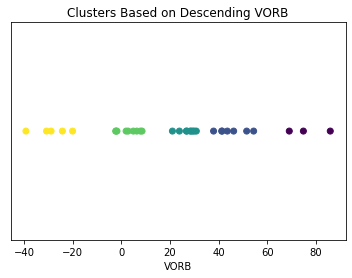

In [ ]:
# Assuming 'VORB_df' is your DataFrame and 'Cluster' is the column containing cluster labels

# Determine the cluster labels and their corresponding maximum 'VORB' values
cluster_max_vorb = VORB_df.groupby('Cluster')['VORB'].max().sort_values(ascending=False)

# Create a mapping between old cluster labels and new labels based on descending 'VORB'
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_max_vorb.index)}

# Apply the new labels to the 'Cluster' column
VORB_df['NewCluster'] = VORB_df['Cluster'].map(cluster_mapping)

# Visualize the clusters with the new labels
plt.scatter(VORB_df['VORB'], [0] * len(VORB_df), c=VORB_df['NewCluster'], cmap='viridis')
plt.title('Clusters Based on Descending VORB')
plt.xlabel('VORB')
plt.yticks([])  # to remove y-axis ticks
plt.show()


In [54]:
import seaborn as sns

# Set a seaborn style
sns.set(style="whitegrid")

# Set the color palette for the clusters
cluster_palette = sns.color_palette("viridis", n_colors=len(VORB_df['NewCluster'].unique()))

# Plot VORB (y-axis) by brewery (x-axis). Color by cluster
plt.figure(figsize=(30, 10))
scatter = plt.scatter(VORB_df['Brewery Name'], VORB_df['VORB'], c=VORB_df['NewCluster'], cmap='viridis', s=300, marker='D')
plt.xticks(rotation=90, fontsize=30, fontname='Trebuchet MS')
plt.yticks(fontsize=30, fontname='Trebuchet MS')

# Add labels and title, set font to trebuchet MS
# plt.title('VORB by Brewery', fontsize=20, fontname='Trebuchet MS')
plt.ylabel('VORB', fontsize=30, fontname='Trebuchet MS')

# Show the plot
plt.show()

# Save the plot
scatter.figure.savefig('vorb_chart.png', bbox_inches='tight')

KeyError: 'NewCluster'

In [53]:
# keep only Image URL, Beer Name, Brewery Name, Style, ABV, My Rating, Global Rating
beer_table = df[['Image URL', 'Beer Name', 'Brewery Name', 'Style', 'ABV', 'My Rating', 'Global Rating']]
# rename columns
beer_table = beer_table.rename(columns={'Image URL': 'Label', 'Beer Name': 'Beer', 'Brewery Name': 'Brewery', 'My Rating': 'My Rating', 'Global Rating': 'Untappd Rating'})
# export the DataFrame to a JSON file
beer_table.to_json('beer_data3.json', orient='records', date_format='iso', default_handler=str)

## plots

In [23]:
# calculate average of the my rating column by brewery

# Group the DataFrame by brewery name and calculate the average, count, standard dev, max of my rating and global rating
beer_df_brewery = df.groupby("Brewery Name").agg({
    "My Rating": ["mean", "count", "max", "std"],
    "Global Rating": ["mean", "std"]
}).reset_index()

# rename columns
beer_df_brewery.columns = ["Brewery Name", "Avg Beer Rating", "Count", "Top Beer Rating", "My StDev", "Global Avg Rating", "Global StDev"]

# keep only breweries with more than 3 beers
# beer_df_brewery = beer_df_brewery[beer_df_brewery["Count"] >= 5]

# create difference column
beer_df_brewery["Diff"] = beer_df_brewery["Avg Beer Rating"] - beer_df_brewery["Global Avg Rating"]

# set minimum sample size
min_sample_size = 3

# # calculate the median absolute difference for breweries with sufficient sample size
# median_abs_diff = beer_df_brewery[beer_df_brewery["Count"] >= min_sample_size]["Diff"].abs().median()

# # rate as ovverated, underrated, or properly rated based on median absolute difference
# beer_df_brewery["OverUnder"] = beer_df_brewery["Diff"].apply(
#     lambda x: "Underrated" if x > median_abs_diff else "Overrated" if x < -median_abs_diff else "Properly Rated")

# # replace if sample size is too small
# beer_df_brewery.loc[beer_df_brewery["Count"] < min_sample_size, "OverUnder"] = "tbd"

# create column for average beer rating without top beer
beer_df_brewery["Avg Beer Rating Without Top"] = (beer_df_brewery["Avg Beer Rating"] * beer_df_brewery["Count"] - beer_df_brewery["Top Beer Rating"]) / (beer_df_brewery["Count"] - 1)

# create a "Brewery Rating" column that is a weighted average of the avg beer rating without top and the top beer rating
beer_df_brewery["Brewery Rating"] = (beer_df_brewery["Avg Beer Rating Without Top"] + beer_df_brewery["Top Beer Rating"]) / 2

# replace if sample size is too small
beer_df_brewery.loc[beer_df_brewery["Count"] < min_sample_size, "Avg Beer Rating Without Top"] = "tbd"
beer_df_brewery.loc[beer_df_brewery["Count"] < min_sample_size, "Brewery Rating"] = "tbd"

# Sort the DataFrame by average rating
#beer_df_brewery = beer_df_brewery.sort_values("Avg Beer Rating", ascending=False)

beer_df_brewery

,Brewery Name,Avg Beer Rating,Count,Top Beer Rating,My StDev,Global Avg Rating,Global StDev,Diff,Avg Beer Rating Without Top,Brewery Rating
0,3 Floyds Brewing,4.00,2,4.25,0.353553,4.100000,0.197990,-0.100000,tbd,tbd
1,Abbaye de Leffe,4.00,1,4.00,NaN,3.580000,NaN,0.420000,tbd,tbd
2,Alewerks Brewing Company,4.00,1,4.00,NaN,4.270000,NaN,-0.270000,tbd,tbd
3,Allagash Brewing Company,4.00,1,4.00,NaN,3.750000,NaN,0.250000,tbd,tbd
4,Anchor Brewing Company,3.25,1,3.25,NaN,3.490000,NaN,-0.240000,tbd,tbd
...,...,...,...,...,...,...,...,...,...,...
145,Wico Street Beer Co.,3.75,1,3.75,NaN,3.920000,NaN,-0.170000,tbd,tbd
146,Woodland Empire Ale Craft,3.75,1,3.75,NaN,3.110000,NaN,0.640000,tbd,tbd
147,Yuengling Brewery,3.25,1,3.25,NaN,3.490000,NaN,-0.240000,tbd,tbd
148,de Garde Brewing,4.00,1,4.00,NaN,4.200000,NaN,-0.200000,tbd,tbd


In [24]:
from scipy import stats

# Assuming you have a DataFrame called df with the required columns
# "My Avg Rating", "My StDev", "Global Avg Rating", "Global StDev", and "Count"

# Calculate the t-test for each brewery
def t_test_for_brewery(row):
    my_avg = row['Avg Beer Rating']
    my_std = row['My StDev']
    global_avg = row['Global Avg Rating']
    global_std = row['Global StDev']
    count = row['Count']

    # Calculate the standard error for the means
    # my_standard_error = my_std / (count ** 0.5)
    # global_standard_error = global_std / (count ** 0.5)

    # Perform the t-test
    t_statistic, p_value = stats.ttest_ind_from_stats(my_avg, my_std, count, global_avg, global_std, count)

    return t_statistic, p_value

In [25]:
# Apply the t-test function to each row
beer_df_brewery['T-Statistic'], beer_df_brewery['P-Value'] = zip(*beer_df_brewery.apply(t_test_for_brewery, axis=1))

# replace as null if sample size is less than 3
beer_df_brewery.loc[beer_df_brewery["Count"] < 3, "T-Statistic"] = None
beer_df_brewery.loc[beer_df_brewery["Count"] < 3, "P-Value"] = None

# add column for overrated or underrated. if p<0.1, then underrated if my avg > global avg, else overrated. if p>0.1, then tbd
# beer_df_brewery.loc[(beer_df_brewery["P-Value"] < 0.2) & (beer_df_brewery["Diff"] > 0.15), "OverUnder"] = "Underrated"
# beer_df_brewery.loc[(beer_df_brewery["P-Value"] < 0.2) & (beer_df_brewery["Diff"] < -0.15), "OverUnder"] = "Overrated"

beer_df_brewery.loc[(beer_df_brewery["Count"] >= 3), "OverUnder"] = "Properly Rated"
beer_df_brewery.loc[(beer_df_brewery["Count"] >= 3) & (beer_df_brewery["Diff"] > 0.15), "OverUnder"] = "Underrated"
beer_df_brewery.loc[(beer_df_brewery["Count"] >= 3) & (beer_df_brewery["Diff"] < -0.15), "OverUnder"] = "Overrated"

# Breweries

In [19]:
# define a function that accepts a url and returns a df
def get_brewery_data(url):
    # Get the webpage content
    response = requests.get(url, headers = {'User-agent': 'your bot 0.1'})
    content = response.text

    # Parse the content using BeautifulSoup
    soup = BeautifulSoup(content, "html.parser")

    # Find the <script> tag containing the JSON data
    json_script = soup.find("script", type="application/ld+json")

    # Extract the JSON data and load it into a Python dictionary
    json_data = json.loads(json_script.string)

    # Create a DataFrame with separate columns for the JSON data
    df = pd.DataFrame({
        'name': [json_data['name']],
        'description': [json_data['description']],
        'image_url': [json_data['image']['contentUrl']],
        'ratingValue': [json_data['aggregateRating']['ratingValue']],
        'bestRating': [json_data['aggregateRating']['bestRating']],
        'reviewCount': [json_data['aggregateRating']['reviewCount']],
        'streetAddress': [json_data['address']['streetAddress']],
        'addressLocality': [json_data['address']['addressLocality']],
        'addressRegion': [json_data['address']['addressRegion']],
        'telephone': [json_data['telephone']],
        'warningservesCuisine': [json_data['warningservesCuisine']]
    })

    # Return the DataFrame
    return df

In [42]:
# get list of unique brewery filepaths
brewery_paths = df['Brewery Filepath'].unique()

In [42]:
# cycle through brewery paths and get data

# # Create an empty DataFrame
# brewery_df = pd.DataFrame()

# for path in brewery_paths:
#     # get the data
#     df_temp = get_brewery_data(path)
#     # Concatenate the data to the DataFrame
#     brewery_df = pd.concat([brewery_df, df_temp], ignore_index=True)
#     # Add a 1-second pause
#     time.sleep(2)

In [38]:
# create new column with full address
brewery_df['full_address'] = brewery_df['streetAddress'] + ', ' + brewery_df['addressLocality'] + ', ' + brewery_df['addressRegion']

In [159]:
# get list of addresses
addresses = brewery_df['full_address']

# add empty columns: Latitude, Longitude, City, State, Country
brewery_df['Latitude'] = ''
brewery_df['Longitude'] = ''
brewery_df['City'] = ''
brewery_df['State'] = ''
brewery_df['Country'] = ''

In [43]:
api_key = 'Al8SFa_2n3r2RePgLvIghCFbznNrtJcRjFKRgkdxPI2VOgI_u1DTPNJdGlJfJAjt'

In [161]:
import geocoder
# loop through addresses, geocode, and add following columns to brewery_df: Latitude, Longitude, City, State, Country
for address in addresses:
    g = geocoder.bing(address, key=api_key)
    brewery_df.loc[brewery_df['full_address'] == address, 'Latitude'] = g.latlng[0]
    brewery_df.loc[brewery_df['full_address'] == address, 'Longitude'] = g.latlng[1]
    brewery_df.loc[brewery_df['full_address'] == address, 'City'] = g.city
    brewery_df.loc[brewery_df['full_address'] == address, 'State'] = g.state
    brewery_df.loc[brewery_df['full_address'] == address, 'Country'] = g.country

In [198]:
brewery_df

,name,description,image_url,ratingValue,bestRating,reviewCount,streetAddress,addressLocality,addressRegion,telephone,warningservesCuisine,full_address,Latitude,Longitude,City,State,Country
0,The Veil Brewing Co.,"Craft brewery located in Richmond and Norfolk,...",https://assets.untappd.com/site/brewery_logos_...,4.169,5,1448589,1509 Belleville St,Richmond,VA,NaN,NaN,"1509 Belleville St, Richmond, VA",37.571290,-77.474632,Richmond,VA,United States
1,Belleflower Brewing,Belleflower is co-owned by the Page and Bonadi...,https://assets.untappd.com/site/brewery_logos_...,4.105,5,59159,66 Cove Street,Portland,ME,NaN,NaN,"66 Cove Street, Portland, ME",43.668219,-70.256662,Portland,ME,United States
2,Deciduous Brewing Company,NaN,https://assets.untappd.com/site/brewery_logos/...,4.049,5,161933,12 Weaver St,Newmarket,NH,NaN,NaN,"12 Weaver St, Newmarket, NH",43.081141,-70.936894,Newmarket,NH,United States
3,Three Notch'd Brewing,"Originally, the Three Notch’d Road was a colon...",https://assets.untappd.com/site/brewery_logos_...,3.743,5,355371,520 2nd St SE,Charlottesville,VA,NaN,NaN,"520 2nd St SE, Charlottesville, VA",38.026121,-78.482181,Charlottesville,VA,United States
4,Right Proper Brewing Company,"Right Proper is a responsible, community focus...",https://assets.untappd.com/site/brewery_logos/...,3.667,5,132302,624 T Street NW,Washington,DC,NaN,NaN,"624 T Street NW, Washington, DC",38.915390,-77.021368,Washington,DC,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Skipping Rock Beer Co.,Worry less. Live more. That’s the Skipping Roc...,https://assets.untappd.com/site/brewery_logos_...,3.824,5,11453,414 Parkersburg Turnpike,Staunton,VA,NaN,NaN,"414 Parkersburg Turnpike, Staunton, VA",38.153501,-79.127503,Staunton,VA,United States
132,Shenandoah Valley Brewing Company,**Closed 10/30/2022**\r\n\r\nShenandoah Valley...,https://assets.untappd.com/site/brewery_logos/...,3.375,5,5300,103 W Beverley St,Staunton,VA,NaN,NaN,"103 W Beverley St, Staunton, VA",38.149606,-79.073894,Staunton,VA,United States
133,Redbeard Brewing,Nanobrewery in the heart of downtown Staunton....,https://assets.untappd.com/site/brewery_logos_...,3.873,5,22491,120 S Lewis St,Staunton,VA,NaN,NaN,"120 S Lewis St, Staunton, VA",38.147546,-79.074610,Staunton,VA,United States
134,SingleCut Beersmiths,Cranking out music obsessed award winning Lage...,https://assets.untappd.com/site/brewery_logos/...,4.011,5,1052228,19-33 37th Street,Astoria,NY,NaN,NaN,"19-33 37th Street, Astoria, NY",40.778394,-73.901551,Queens,NY,United States


In [163]:
# export brewery data to csv
# brewery_df.to_csv('brewery_data.csv', index=False)

In [47]:
# import brewery data
brewery_df = pd.read_csv('brewery_data.csv')

In [27]:
# merge in beer_df_brewery data
brewery_df = pd.merge(brewery_df, beer_df_brewery, how='outer', left_on='name', right_on='Brewery Name')

In [28]:
# count if name is missing
print("Number of breweries with missing names: " + str(brewery_df['name'].isnull().sum()))

Number of breweries with missing names: 14


In [31]:
# keep breweries with missing names (name only)
brewery_df_missing = brewery_df[brewery_df['name'].isnull()][['Brewery Name']]

In [33]:
# merge in brewery filepath from df
brewery_df_missing = pd.merge(brewery_df_missing, df[['Brewery Name', 'Brewery Filepath']], how='left', on='Brewery Name')

In [34]:
brewery_df_missing

,Brewery Name,Brewery Filepath
0,Blue Moon Brewing Company,https://untappd.com/BlueMoonBrewingCompany
1,Cloudburst Brewing,https://untappd.com/CloudburstBrewing
2,Groove Brewing,https://untappd.com/GrooveBrewing
3,Holy Mountain Brewing,https://untappd.com/HolyMountainBrewing
4,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing
5,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing
6,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing
7,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing
8,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing
9,Kettlehead Brewing,https://untappd.com/Kettlehead_Brewing


In [36]:
# get list of unique brewery filepaths
brewery_paths_missing = brewery_df_missing['Brewery Filepath'].unique()

In [38]:
# cycle through brewery paths and get data

# Create an empty DataFrame
brewery_df_updates = pd.DataFrame()

for path in brewery_paths_missing:
    # get the data
    df_temp = get_brewery_data(path)
    # Concatenate the data to the DataFrame
    brewery_df_updates = pd.concat([brewery_df_updates, df_temp], ignore_index=True)
    # Add a 1-second pause
    time.sleep(2)

In [40]:
brewery_df_updates.head(2)

,name,description,image_url,ratingValue,bestRating,reviewCount,streetAddress,addressLocality,addressRegion,telephone,warningservesCuisine
0,Blue Moon Brewing Company,We craft our beers with flavorful ingredients ...,https://assets.untappd.com/site/brewery_logos/...,3.392,5,1619152,3750 Chestnut Pl,Denver,CO,,
1,Cloudburst Brewing,"2021 GABF Brewery and Brewer of the Year (1,00...",https://assets.untappd.com/site/brewery_logos_...,3.998,5,161130,2116 Western Ave,Seattle,WA,,


In [41]:
# create new column with full address
brewery_df_updates['full_address'] = brewery_df_updates['streetAddress'] + ', ' + brewery_df_updates['addressLocality'] + ', ' + brewery_df_updates['addressRegion']

# get list of addresses
addresses = brewery_df_updates['full_address']

# add empty columns: Latitude, Longitude, City, State, Country
brewery_df_updates['Latitude'] = ''
brewery_df_updates['Longitude'] = ''
brewery_df_updates['City'] = ''
brewery_df_updates['State'] = ''
brewery_df_updates['Country'] = ''

In [44]:
import geocoder
# loop through addresses, geocode, and add following columns to brewery_df: Latitude, Longitude, City, State, Country
for address in addresses:
    g = geocoder.bing(address, key=api_key)
    brewery_df_updates.loc[brewery_df_updates['full_address'] == address, 'Latitude'] = g.latlng[0]
    brewery_df_updates.loc[brewery_df_updates['full_address'] == address, 'Longitude'] = g.latlng[1]
    brewery_df_updates.loc[brewery_df_updates['full_address'] == address, 'City'] = g.city
    brewery_df_updates.loc[brewery_df_updates['full_address'] == address, 'State'] = g.state
    brewery_df_updates.loc[brewery_df_updates['full_address'] == address, 'Country'] = g.country

In [51]:
# concatenate brewery_df and brewery_df_updates
brewery_df = pd.concat([brewery_df, brewery_df_updates], ignore_index=True)

In [53]:
# save brewery_df to csv
brewery_df.to_csv('brewery_data_1.23.csv', index=False)

In [54]:
brewery_df

,name,description,image_url,ratingValue,bestRating,reviewCount,streetAddress,addressLocality,addressRegion,telephone,warningservesCuisine,full_address,Latitude,Longitude,City,State,Country
0,The Veil Brewing Co.,"Craft brewery located in Richmond and Norfolk,...",https://assets.untappd.com/site/brewery_logos_...,4.169,5,1448589,1509 Belleville St,Richmond,VA,NaN,NaN,"1509 Belleville St, Richmond, VA",37.57129,-77.474632,Richmond,VA,United States
1,Belleflower Brewing,Belleflower is co-owned by the Page and Bonadi...,https://assets.untappd.com/site/brewery_logos_...,4.105,5,59159,66 Cove Street,Portland,ME,NaN,NaN,"66 Cove Street, Portland, ME",43.668219,-70.256662,Portland,ME,United States
2,Deciduous Brewing Company,NaN,https://assets.untappd.com/site/brewery_logos/...,4.049,5,161933,12 Weaver St,Newmarket,NH,NaN,NaN,"12 Weaver St, Newmarket, NH",43.081141,-70.936894,Newmarket,NH,United States
3,Three Notch'd Brewing,"Originally, the Three Notch’d Road was a colon...",https://assets.untappd.com/site/brewery_logos_...,3.743,5,355371,520 2nd St SE,Charlottesville,VA,NaN,NaN,"520 2nd St SE, Charlottesville, VA",38.026121,-78.482181,Charlottesville,VA,United States
4,Right Proper Brewing Company,"Right Proper is a responsible, community focus...",https://assets.untappd.com/site/brewery_logos/...,3.667,5,132302,624 T Street NW,Washington,DC,NaN,NaN,"624 T Street NW, Washington, DC",38.91539,-77.021368,Washington,DC,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Russian River Brewing Company,Russian River Brewing Company was founded by K...,https://assets.untappd.com/site/brewery_logos/...,4.171,5,1363647,700 Mitchell Ln,Windsor,CA,,,"700 Mitchell Ln, Windsor, CA",38.532039,-122.799635,Windsor,CA,United States
146,Spoetzl Brewery,"The Spoetzl Brewery was founded in Shiner, Tex...",https://assets.untappd.com/site/brewery_logos_...,3.442,5,1392699,603 East Brewery Street,Shiner,TX,,,"603 East Brewery Street, Shiner, TX",29.43345,-97.167591,Shiner,TX,United States
147,Tired Hands Brewing Company,,https://assets.untappd.com/site/brewery_logos/...,4.098,5,1677980,35 Cricket Terrace,Ardmore,PA,,,"35 Cricket Terrace, Ardmore, PA",40.006853,-75.290321,Ardmore,PA,United States
148,Vault Brewing Company,"Beer, Pizza, and Jazz. Our Beer is brewed in-h...",https://assets.untappd.com/site/brewery_logos/...,3.801,5,141845,10 South Main St.,Yardley,PA,,,"10 South Main St., Yardley, PA",40.242342,-74.838504,Yardley,PA,United States


In [55]:
# convert brewery_df to geodataframe

# create a geometry column
brewery_df['geometry'] = brewery_df.apply(lambda x: Point((float(x.Longitude), float(x.Latitude))), axis=1)

# create a geodataframe
brewery_gdf = gpd.GeoDataFrame(brewery_df, geometry='geometry')

/Users/jacob/opt/anaconda3/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:122: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [62]:
# export the gdf as a geojson
brewery_gdf.to_file("brewery_data.geojson", driver='GeoJSON')

In [60]:
# merge in beer_df_brewery data
brewery_gdf = pd.merge(brewery_gdf, beer_df_brewery, how='left', left_on='name', right_on='Brewery Name')

In [61]:
brewery_gdf

,name,description,image_url,ratingValue,bestRating,reviewCount,streetAddress,addressLocality,addressRegion,telephone,...,Top Beer Rating,My StDev,Global Avg Rating,Global StDev,Diff,Avg Beer Rating Without Top,Brewery Rating,T-Statistic,P-Value,OverUnder
0,The Veil Brewing Co.,"Craft brewery located in Richmond and Norfolk,...",https://assets.untappd.com/site/brewery_logos_...,4.169,5,1448589,1509 Belleville St,Richmond,VA,NaN,...,4.75,0.353553,4.244000,0.093434,0.006000,4.125,4.4375,0.036688,0.971633,Properly Rated
1,Belleflower Brewing,Belleflower is co-owned by the Page and Bonadi...,https://assets.untappd.com/site/brewery_logos_...,4.105,5,59159,66 Cove Street,Portland,ME,NaN,...,4.25,0.500000,4.096667,0.207926,-0.346667,3.5,3.875,-1.108833,0.329678,Overrated
2,Deciduous Brewing Company,NaN,https://assets.untappd.com/site/brewery_logos/...,4.049,5,161933,12 Weaver St,Newmarket,NH,NaN,...,3.75,NaN,4.290000,NaN,-0.540000,tbd,tbd,NaN,NaN,NaN
3,Three Notch'd Brewing,"Originally, the Three Notch’d Road was a colon...",https://assets.untappd.com/site/brewery_logos_...,3.743,5,355371,520 2nd St SE,Charlottesville,VA,NaN,...,3.25,0.353553,3.800000,0.098995,-0.800000,tbd,tbd,NaN,NaN,NaN
4,Right Proper Brewing Company,"Right Proper is a responsible, community focus...",https://assets.untappd.com/site/brewery_logos/...,3.667,5,132302,624 T Street NW,Washington,DC,NaN,...,3.75,0.176777,3.640000,0.028284,-0.015000,tbd,tbd,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Russian River Brewing Company,Russian River Brewing Company was founded by K...,https://assets.untappd.com/site/brewery_logos/...,4.171,5,1363647,700 Mitchell Ln,Windsor,CA,,...,4.25,NaN,4.500000,NaN,-0.250000,tbd,tbd,NaN,NaN,NaN
146,Spoetzl Brewery,"The Spoetzl Brewery was founded in Shiner, Tex...",https://assets.untappd.com/site/brewery_logos_...,3.442,5,1392699,603 East Brewery Street,Shiner,TX,,...,3.75,NaN,3.500000,NaN,0.250000,tbd,tbd,NaN,NaN,NaN
147,Tired Hands Brewing Company,,https://assets.untappd.com/site/brewery_logos/...,4.098,5,1677980,35 Cricket Terrace,Ardmore,PA,,...,3.50,NaN,4.220000,NaN,-0.720000,tbd,tbd,NaN,NaN,NaN
148,Vault Brewing Company,"Beer, Pizza, and Jazz. Our Beer is brewed in-h...",https://assets.untappd.com/site/brewery_logos/...,3.801,5,141845,10 South Main St.,Yardley,PA,,...,2.75,NaN,3.970000,NaN,-1.220000,tbd,tbd,NaN,NaN,NaN


In [59]:
beer_df_brewery

,Brewery Name,Avg Beer Rating,Count,Top Beer Rating,My StDev,Global Avg Rating,Global StDev,Diff,Avg Beer Rating Without Top,Brewery Rating,T-Statistic,P-Value,OverUnder
0,3 Floyds Brewing,4.00,2,4.25,0.353553,4.100000,0.197990,-0.100000,tbd,tbd,NaN,NaN,NaN
1,Abbaye de Leffe,4.00,1,4.00,NaN,3.580000,NaN,0.420000,tbd,tbd,NaN,NaN,NaN
2,Alewerks Brewing Company,4.00,1,4.00,NaN,4.270000,NaN,-0.270000,tbd,tbd,NaN,NaN,NaN
3,Allagash Brewing Company,4.00,1,4.00,NaN,3.750000,NaN,0.250000,tbd,tbd,NaN,NaN,NaN
4,Anchor Brewing Company,3.25,1,3.25,NaN,3.490000,NaN,-0.240000,tbd,tbd,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Wico Street Beer Co.,3.75,1,3.75,NaN,3.920000,NaN,-0.170000,tbd,tbd,NaN,NaN,NaN
146,Woodland Empire Ale Craft,3.75,1,3.75,NaN,3.110000,NaN,0.640000,tbd,tbd,NaN,NaN,NaN
147,Yuengling Brewery,3.25,1,3.25,NaN,3.490000,NaN,-0.240000,tbd,tbd,NaN,NaN,NaN
148,de Garde Brewing,4.00,1,4.00,NaN,4.200000,NaN,-0.200000,tbd,tbd,NaN,NaN,NaN


In [ ]:
# conduct t-test to see if my ratings are significantly different from global ratings for each brewery
from scipy import stats

# create empty lists to store results
brewery_names = []
t_stats = []
p_values = []

# loop through breweries
for brewery in brewery_df['name']:
    # get my ratings for this brewery
    my_ratings = df[df['Brewery Name'] == brewery]['My Rating']
    # get global ratings for this brewery
    global_ratings = df[df['Brewery Name'] == brewery]['Global Rating']
    # conduct t-test
    t_stat, p_value = stats.ttest_ind(my_ratings, global_ratings, equal_var=False)
    # append results to lists
    brewery_names.append(brewery)
    t_stats.append(t_stat)
    p_values.append(p_value)

note: freak folk address wrong, maybe others. add check for state \
collapse hill farmstead and grassroots?

In [217]:
# export df to html
df.to_html('beer_data.html', index=False)

In [38]:
# calculate weighted average beer rating for each state
# multiply avg beer rating by count to get total rating
brewery_df['Total Rating'] = brewery_df['Avg Beer Rating'] * brewery_df['Count']

# group by state and sum total rating and count
brewery_df_state = brewery_df.groupby('State').agg({
    'Total Rating': 'sum',
    'Count': 'sum'
}).reset_index()

# calculate weighted average beer rating
brewery_df_state['Avg Beer Rating'] = brewery_df_state['Total Rating'] / brewery_df_state['Count']

# keep if count is greater than 5
brewery_df_state = brewery_df_state[brewery_df_state['Count'] >= 5]

In [39]:
brewery_df_state

,State,Total Rating,Count,Avg Beer Rating
2,Bavaria,46.50,12,3.875000
3,CA,36.75,10,3.675000
5,DC,79.00,21,3.761905
10,GA,17.25,5,3.450000
12,ID,18.50,5,3.700000
20,MA,101.25,26,3.894231
22,ME,35.25,9,3.916667
28,NY,89.25,23,3.880435
32,Quebec,18.75,5,3.750000
38,VA,270.00,73,3.698630


# update brewery data

In [43]:
# import brewery data
brewery_df = pd.read_csv('brewery_data.csv')

# merge in beer_df_brewery data
brewery_df = pd.merge(brewery_df, beer_df_brewery, how='left', left_on='name', right_on='Brewery Name')

# merge in VORB_df data
brewery_df = pd.merge(brewery_df, VORB_df, how='left', left_on='name', right_on='Brewery Name')

# drop if count is less than 3
brewery_df = brewery_df[brewery_df['Count'] >= 3]

# sort by VORB (descending)
brewery_df = brewery_df.sort_values(by=['VORB'], ascending=False)

# keep name, image_url, State, Country, Avg Beer Rating, Count, Top Beer Rating, Global Avg Rating, Diff, VORB
brewery_df = brewery_df[['name', 'image_url', 'State', 'Country', 'Avg Beer Rating', 'Count', 'Top Beer Rating', 'Global Avg Rating', 'Diff', 'VORB']]

In [44]:
brewery_df

,name,image_url,State,Country,Avg Beer Rating,Count,Top Beer Rating,Global Avg Rating,Diff,VORB
34,Hill Farmstead Brewery,https://assets.untappd.com/site/brewery_logos/...,VT,United States,4.482143,14,5.00,4.293571,0.188571,85.958297
70,Fidens Brewing Co,https://assets.untappd.com/site/brewery_logos_...,NY,United States,4.464286,7,4.75,4.398571,0.065714,74.896801
90,Tree House Brewing Company,https://assets.untappd.com/site/brewery_logos/...,MA,United States,4.357143,14,4.75,4.410714,-0.053571,69.097788
32,Toppling Goliath Brewing Co.,https://assets.untappd.com/site/brewery_logos_...,IA,United States,4.312500,4,4.50,4.272500,0.040000,54.436275
46,River Roost Brewery,https://assets.untappd.com/site/brewery_logos/...,VT,United States,4.111111,9,4.75,4.193333,-0.082222,51.571637
0,The Veil Brewing Co.,https://assets.untappd.com/site/brewery_logos_...,VA,United States,4.250000,5,4.75,4.244000,0.006000,46.217849
61,von Trapp Brewing,https://assets.untappd.com/site/brewery_logos/...,VT,United States,4.250000,3,4.50,3.683333,0.566667,43.627451
63,BreWskey,https://assets.untappd.com/site/brewery_logos_...,Quebec,Canada,4.083333,3,4.50,4.286667,-0.203333,41.471018
31,Other Half Brewing Co.,https://assets.untappd.com/site/brewery_logos_...,NY,United States,4.035714,14,4.50,4.222857,-0.187143,41.311275
36,Lawson's Finest Liquids,https://assets.untappd.com/site/brewery_logos_...,VT,United States,4.050000,5,4.50,4.008000,0.042000,37.953646


In [45]:
# Export the DataFrame to a JSON file with commas at the end of each line
brewery_json = 'brewery_data.json'
with open(brewery_json, 'w') as file:
    # Generate the JSON content without line breaks and special character conversion
    json_content = brewery_df.to_json(orient='records', lines=True, date_format='iso', default_handler=str, force_ascii=False)
    
    # Split the content into lines
    lines = json_content.split('\n')
    
    # Add a comma at the end of each line (except for the last line)
    for line in lines[:-1]:
        file.write(line + ',\n')
    
    # Write the last line without a comma
    file.write(lines[-1])